logistic regression over ad text to score each ad's probability of being political content. labels come from the curated hashtag csvs from nb 04b — ads carrying a known-political hashtag are positives, ads carrying a known-non-political hashtag are negatives. hashtags themselves are stripped from the text before vectorising so the model has to learn from the surrounding prose, not the labels. then score every v3 advocacy ad and aggregate per advertiser per week to look for pivot patterns.

In [18]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, when, lit, lower, regexp_replace, concat_ws, array_join, broadcast,
    sum as spark_sum, count as spark_count, date_trunc, desc, abs as spark_abs,
    mean as spark_mean,
)
from pyspark.sql.window import Window
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    RegexTokenizer, StopWordsRemover, CountVectorizer, IDF,
)
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

spark = SparkSession.builder \
    .appName('FB_API_election_content_clf') \
    .config('spark.sql.parquet.output.committer.class',
            'org.apache.parquet.hadoop.ParquetOutputCommitter') \
    .config('mapreduce.fileoutputcommitter.algorithm.version', '2') \
    .getOrCreate()

print('Master:', spark.sparkContext.master)
print('Spark version:', spark.version)

Master: yarn
Spark version: 3.5.0


In [19]:
V3_PATH = '/user/s3348393/main/preprocessing/v3/parquet'
POLITICAL_CSV     = '../data/hashtags_political.csv'
NON_POLITICAL_CSV = '../data/hashtags_non_political.csv'
BANDS_CSV         = '../data/all_bylines_bands.csv'   # used for downstream comparison only
ELECTION_DATE = pd.Timestamp('2022-05-21')
WINDOW_START = pd.Timestamp('2021-11-21')
WINDOW_END   = pd.Timestamp('2022-11-21')

# hot zone is only used downstream for FP/FN checks and pivot detection.
HOT_ZONE_WEEKS = 4
hot_start = (ELECTION_DATE - pd.Timedelta(weeks=HOT_ZONE_WEEKS)).date().isoformat()
hot_end   = (ELECTION_DATE + pd.Timedelta(weeks=HOT_ZONE_WEEKS)).date().isoformat()

load v3 advocacy ads, detect political and non-political hashtag presence per ad, then strip the hashtags from the text so the model learns from the surrounding prose, not the labels. also attach band labels from nb 05 for downstream comparison.

In [20]:
import re

v3 = spark.read.parquet(V3_PATH).filter(col('match_type').isNull())

# combine body + title arrays into one raw text blob, lowercase.
v3 = v3.withColumn('raw_text', lower(concat_ws(' ',
    array_join('creative_bodies', ' '),
    array_join('creative_link_titles', ' '))))
v3 = v3.filter(col('raw_text').isNotNull() & (col('raw_text') != ''))

# load curated hashtag lists.
political_hashtags     = set(pd.read_csv(POLITICAL_CSV)['hashtag'].str.lower())
non_political_hashtags = set(pd.read_csv(NON_POLITICAL_CSV)['hashtag'].str.lower())
print(f'Political hashtags loaded:     {len(political_hashtags)}')
print(f'Non-political hashtags loaded: {len(non_political_hashtags)}')

def _make_hashtag_regex(tags):
    if not tags:
        return r'(?!.*)'  # never matches
    return r'#(' + '|'.join(re.escape(t) for t in tags) + r')\b'

pol_re = _make_hashtag_regex(political_hashtags)
non_re = _make_hashtag_regex(non_political_hashtags)

v3 = v3.withColumn('has_political_hashtag',     col('raw_text').rlike(pol_re))
v3 = v3.withColumn('has_non_political_hashtag', col('raw_text').rlike(non_re))

# strip all hashtags from text before further processing — the model must learn
# from the prose, not from the hashtags themselves (which are the labels).
v3 = v3.withColumn('text', regexp_replace(col('raw_text'), r'#\w+', ' '))
v3 = v3.withColumn('text', regexp_replace(col('text'), r'[^a-z\s]', ' '))

# attach band labels for downstream comparison only.
try:
    bands_pdf = pd.read_csv(BANDS_CSV)[['bylines', 'band']]
    bands_sdf = spark.createDataFrame(bands_pdf)
    v3 = v3.join(broadcast(bands_sdf), 'bylines', 'left')
    have_bands = True
except FileNotFoundError:
    v3 = v3.withColumn('band', lit(None).cast('string'))
    have_bands = False
    print('Bands csv not found — band column will be null.')

v3 = v3.cache()
print(f'\nAdvocacy ads with text: {v3.count():,}')
print('\nHashtag-tag flags:')
v3.groupBy('has_political_hashtag', 'has_non_political_hashtag').count().show()

Political hashtags loaded:     210
Non-political hashtags loaded: 286



Advocacy ads with text: 94,358

Hashtag-tag flags:
+---------------------+-------------------------+-----+
|has_political_hashtag|has_non_political_hashtag|count|
+---------------------+-------------------------+-----+
|                 true|                    false| 2599|
|                 true|                     true| 1074|
|                false|                    false|85423|
|                false|                     true| 5262|
+---------------------+-------------------------+-----+



build the labelled training set. positive = ad contains at least one political hashtag and no non-political hashtag. negative = ad contains at least one non-political hashtag and no political hashtag. ads with mixed signal (both kinds of hashtag) or no hashtag at all are unlabelled — they get scored later at inference.

In [21]:
labelled = v3.withColumn('label',
    when( col('has_political_hashtag') & ~col('has_non_political_hashtag'), lit(1.0))
    .when(~col('has_political_hashtag') &  col('has_non_political_hashtag'), lit(0.0))
    .otherwise(lit(None))
)

train_full = labelled.filter(col('label').isNotNull()).cache()

print('Class balance:')
train_full.groupBy('label').count().show()

print('Distinct positive-class bylines:',
      train_full.filter(col('label') == 1.0).select('bylines').distinct().count())
print('Distinct negative-class bylines:',
      train_full.filter(col('label') == 0.0).select('bylines').distinct().count())

print('\nPositive class — top contributing bylines:')
train_full.filter(col('label') == 1.0).groupBy('bylines').count() \
    .orderBy(desc('count')).show(10, truncate=False)

print('Negative class — top contributing bylines:')
train_full.filter(col('label') == 0.0).groupBy('bylines').count() \
    .orderBy(desc('count')).show(10, truncate=False)

Class balance:
+-----+-----+
|label|count|
+-----+-----+
|  0.0| 5262|
|  1.0| 2599|
+-----+-----+

Distinct positive-class bylines: 259
Distinct negative-class bylines: 303

Positive class — top contributing bylines:
+-----------------------------------------+-----+
|bylines                                  |count|
+-----------------------------------------+-----+
|Australian Education Union               |255  |
|James Oliver Gibson                      |231  |
|It's Not A Race                          |131  |
|polipedia.com.au                         |81   |
|Craig Ondarchie MP                       |73   |
|First Tier Media                         |69   |
|Australian Education Union Federal Branch|64   |
|Cape York Institute                      |62   |
|Australian Parents for Climate Action    |50   |
|United Workers Union                     |43   |
+-----------------------------------------+-----+
only showing top 10 rows

Negative class — top contributing bylines:
+------------

tokenise, drop stopwords, vectorise. uses spark mllib's pipeline so the same transform applies at inference time.

In [22]:
tokenizer = RegexTokenizer(inputCol='text', outputCol='tokens',
                            pattern=r'\s+', minTokenLength=4)

# election seeds are NOT in the stopword list — they're the obvious election
# vocabulary the model should be allowed to use as features. the seed list is
# only used in cell 4 as a positive-class filter to drop non-political bylines
# whose spend timing happens to look election-aligned.
stop_words = list(set(StopWordsRemover.loadDefaultStopWords('english')) | {
    'australia', 'australian', 'australians', 'sign', 'petition', 'please',
    'today', 'help', 'one', 'go', 'http', 'https', 'www', 'com',
    # calendar-month leakage — these correlate with the election window for
    # trivial temporal reasons, not content.
    'january', 'february', 'march', 'april', 'may', 'june',
    'july', 'august', 'september', 'october', 'november', 'december',
    'eofy',
})

remover = StopWordsRemover(inputCol='tokens', outputCol='tokens_clean',
                            stopWords=stop_words)

cv = CountVectorizer(inputCol='tokens_clean', outputCol='tf',
                      minDF=20, maxDF=0.3, vocabSize=5000)
idf = IDF(inputCol='tf', outputCol='features')
lr  = LogisticRegression(featuresCol='features', labelCol='label',
                          maxIter=50, regParam=0.01)

pipeline = Pipeline(stages=[tokenizer, remover, cv, idf, lr])

train/test split 80/20, fit, evaluate.

In [23]:
train, test = train_full.randomSplit([0.8, 0.2], seed=42)
train = train.cache()
test = test.cache()

print(f'train: {train.count():,}')
print(f'test:  {test.count():,}')

model = pipeline.fit(train)
pred = model.transform(test).cache()

train: 6,353
test:  1,508


auc and confusion-matrix metrics on the held-out test set.

In [24]:
auc_eval = BinaryClassificationEvaluator(labelCol='label', metricName='areaUnderROC')
auc = auc_eval.evaluate(pred)
print(f'AUC: {auc:.4f}')

for metric in ['accuracy', 'weightedPrecision', 'weightedRecall', 'f1']:
    e = MulticlassClassificationEvaluator(labelCol='label',
                                            predictionCol='prediction',
                                            metricName=metric)
    print(f'{metric}: {e.evaluate(pred):.4f}')

print('\nConfusion matrix (label × prediction):')
pred.groupBy('label', 'prediction').count().orderBy('label', 'prediction').show()

AUC: 0.9738
accuracy: 0.9350
weightedPrecision: 0.9348
weightedRecall: 0.9350
f1: 0.9348

Confusion matrix (label × prediction):
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|  966|
|  0.0|       1.0|   44|
|  1.0|       0.0|   54|
|  1.0|       1.0|  444|
+-----+----------+-----+



leave-one-advertiser-out validation. for each election_only advertiser, hold their ads out, retrain on the rest, and score the held-out advertiser's pre-election ads. if precision stays high across all hold-outs, the model is learning content not advertiser identity. if it collapses for any one, the model was leaning on that advertiser's vocabulary.

In [25]:
# leave-one-advertiser-out across the bylines contributing the most positive
# examples. with hashtag-based labels the positive class draws from dozens of
# distinct bylines, so loo over the top contributors is a good generalisation
# check — if holding one big positive-class byline out tanks the model, the
# model was leaning on their style.
TOP_N_BYLINES_TO_LOO = 15

positive_bylines_pdf = (train_full.filter(col('label') == 1.0)
                       .groupBy('bylines').count()
                       .orderBy(desc('count'))
                       .limit(TOP_N_BYLINES_TO_LOO)
                       .toPandas())
loo_bylines = positive_bylines_pdf['bylines'].tolist()
print(f'LOO over top {len(loo_bylines)} positive-class bylines.')

loo_results = []
for held_out in loo_bylines:
    train_loo = train_full.filter(col('bylines') != held_out)
    held_ads  = train_full.filter((col('bylines') == held_out) &
                                   (col('label') == 1.0))
    n_held = held_ads.count()
    if n_held == 0:
        continue

    m = pipeline.fit(train_loo)
    p = m.transform(held_ads).select('prediction').toPandas()
    held_recall = (p['prediction'] == 1.0).mean()
    loo_results.append({
        'held_out': held_out,
        'n_ads_held_out': n_held,
        'recall_on_held_out': held_recall,
    })

loo_df = pd.DataFrame(loo_results).sort_values('recall_on_held_out')
display(loo_df)

unweighted_mean = loo_df['recall_on_held_out'].mean()
min_recall      = loo_df['recall_on_held_out'].min()
weighted_mean   = ((loo_df['recall_on_held_out'] * loo_df['n_ads_held_out']).sum() /
                    loo_df['n_ads_held_out'].sum())

print(f'\nUnweighted mean recall:  {unweighted_mean:.3f}')
print(f'Ad-weighted mean recall: {weighted_mean:.3f}')
print(f'Min recall (any byline): {min_recall:.3f}')

LOO over top 15 positive-class bylines.


,held_out,n_ads_held_out,recall_on_held_out
8,Australian Parents for Climate Action,50,0.000000
3,polipedia.com.au,81,0.086420
2,It's Not A Race,131,0.229008
14,Brad Battin MP,32,0.375000
10,The Climate Council,42,0.476190
7,Cape York Institute,62,0.516129
1,James Oliver Gibson,231,0.545455
11,Bill Tilley MP,38,0.605263
4,Craig Ondarchie MP,73,0.630137
9,United Workers Union,43,0.790698



Unweighted mean recall:  0.603
Ad-weighted mean recall: 0.612
Min recall (any byline): 0.000


apply the model to every v3 advocacy ad, extracting the probability of class 1 (election-content).

In [26]:
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

extract_prob = udf(lambda v: float(v[1]), DoubleType())

scored = (model.transform(v3)
    .withColumn('election_prob', extract_prob('probability'))
    .select('id', 'bylines', 'page_name', 'ad_creation_date',
            'spend_mid', 'text', 'election_prob')
    .cache())

print(f'Scored ads: {scored.count():,}')

Scored ads: 94,358


false-positive check. take ads with the highest election_prob but from advertisers we'd intuitively expect to score low (i.e. ongoing humanitarian / environmental advertisers, far away from election day). if the model is well-calibrated, these should genuinely contain election-themed content. if not, the model is over-firing.

In [27]:
# ads from outside the hot zone with very high election_prob
fp_check = (scored
    .filter((col('ad_creation_date') < lit(hot_start)) |
            (col('ad_creation_date') > lit(hot_end)))
    .filter(col('election_prob') > 0.85)
    .orderBy(desc('election_prob'))
    .limit(30)
    .toPandas())

fp_check['text_preview'] = fp_check['text'].str[:120]
print('High-scoring ads from outside hot zone (potential false positives):')
display(fp_check[['bylines', 'ad_creation_date', 'election_prob', 'text_preview']])

High-scoring ads from outside hot zone (potential false positives):


,bylines,ad_creation_date,election_prob,text_preview
0,Health Care Providers Association,2022-08-12,1.0,what if you could get funded by the government...
1,Ananda Ranga Lalbahadur Sunkanpally,2022-11-06,1.0,i am your best choice i am the most...
2,Ananda Ranga Lalbahadur Sunkanpally,2022-10-07,1.0,with the respect and dignity i fly high \n\n...
3,Health Care Providers Association,2022-08-12,1.0,are you an accountant or a book keeper \nby be...
4,Ananda Ranga Lalbahadur Sunkanpally,2022-10-25,1.0,i am your best choice i am the most...
5,Ananda Ranga Lalbahadur Sunkanpally,2022-10-11,1.0,i am your best choice \ni request you to vo...
6,Steven B Hughes,2022-09-22,1.0,why did the chicken cross the road because co...
7,Ananda Ranga Lalbahadur Sunkanpally,2022-09-25,1.0,i request you to vote for me sunkanpally a...
8,Ananda Ranga Lalbahadur Sunkanpally,2022-10-10,1.0,to all beloved north ward council voters city...
9,Ananda Ranga Lalbahadur Sunkanpally,2022-10-25,1.0,i am your best choice i am the most...


aggregate per advertiser. for each byline compute total spend and spend-weighted mean election_prob. high mean = advertiser's portfolio is dominated by election content. low mean = mostly non-election content.

In [28]:
from pyspark.sql.functions import sum as spark_sum, avg

per_advertiser = (scored
    .filter(col('bylines').isNotNull() & col('spend_mid').isNotNull())
    .withColumn('weighted_prob', col('election_prob') * col('spend_mid'))
    .groupBy('bylines')
    .agg(
        spark_sum('spend_mid').alias('total_spend'),
        spark_sum('weighted_prob').alias('weighted_prob_sum'),
        spark_count('*').alias('n_ads'),
    )
    .withColumn('mean_election_prob_weighted',
                col('weighted_prob_sum') / col('total_spend'))
    .orderBy(desc('total_spend'))
    .toPandas())

top30 = per_advertiser.head(30).reset_index(drop=True)
display(top30[['bylines', 'total_spend', 'n_ads', 'mean_election_prob_weighted']])

,bylines,total_spend,n_ads,mean_election_prob_weighted
0,Greenpeace Australia Pacific,1556769.5,9661,0.118278
1,Amnesty International Australia,854819.0,2262,0.283277
2,Solutions for Australia,656140.5,1819,0.425051
3,Australian Conservation Foundation,644985.5,2229,0.354141
4,Climate 200,629674.5,1351,0.775033
5,Thrive By Five,612850.0,1100,0.727414
6,Australian Unions,543427.5,545,0.395147
7,Australia for UNHCR,514934.5,1331,0.239935
8,Future Super,402754.0,292,0.507733
9,Plan International Australia,378201.5,397,0.188576


compute a single content classifier metric per advertiser: the mean election_prob across ads created in the pre-election window (4 weeks before polling day). exported as data/content_classifier_per_advertiser.csv for nb 07 (combined PAC ranking).

In [29]:
from pyspark.sql.functions import mean as spark_mean

advertiser_pre = (scored
    .filter(col('bylines').isNotNull())
    .filter((col('ad_creation_date') >= lit(hot_start)) &
            (col('ad_creation_date') <  lit(ELECTION_DATE.date().isoformat())))
    .groupBy('bylines')
    .agg(spark_mean('election_prob').alias('mean_prob_pre'),
         spark_count('*').alias('n_ads_pre'))
    .toPandas())

content_export = advertiser_pre.merge(
    per_advertiser[['bylines', 'total_spend', 'n_ads', 'mean_election_prob_weighted']],
    on='bylines', how='outer')

CONTENT_SCORES_CSV = '../data/content_classifier_per_advertiser.csv'
content_export.to_csv(CONTENT_SCORES_CSV, index=False)
print(f'Wrote {CONTENT_SCORES_CSV}  ({len(content_export):,} advertisers)')

# Preview --- top 20 by pre-election content score
display(content_export.sort_values('mean_prob_pre', ascending=False).head(20))

Wrote ../data/content_classifier_per_advertiser.csv  (2,439 advertisers)


,bylines,mean_prob_pre,n_ads_pre,total_spend,n_ads,mean_election_prob_weighted
638,The Executive Council of Australian Jewry (ECAJ),1.000000,2.0,546.5,7,0.378489
392,Sustainable Australia Party,0.999999,3.0,3535.5,29,0.683893
486,Andrew John Bartlett,0.999998,1.0,49.5,1,0.999998
273,Doctors of,0.999990,1.0,1096.0,8,0.872313
103,Project Planet Australia Inc,0.999988,9.0,445.5,9,0.999988
667,David Andrew Fulton,0.999971,2.0,247.5,5,0.412768
79,Alison Champion,0.999944,1.0,1644.5,11,0.428964
126,Anthony Peck,0.999923,1.0,49.5,1,0.999923
402,Mitchell Cameron Griffin,0.999894,2.0,148.5,3,0.735984
495,Mornington Peninsula Climate Action Network,0.999870,3.0,248.5,3,0.999922


pre-election content score bar chart for the top-20 spenders --- sorted descending so the most election-content-heavy advertiser is at the top.

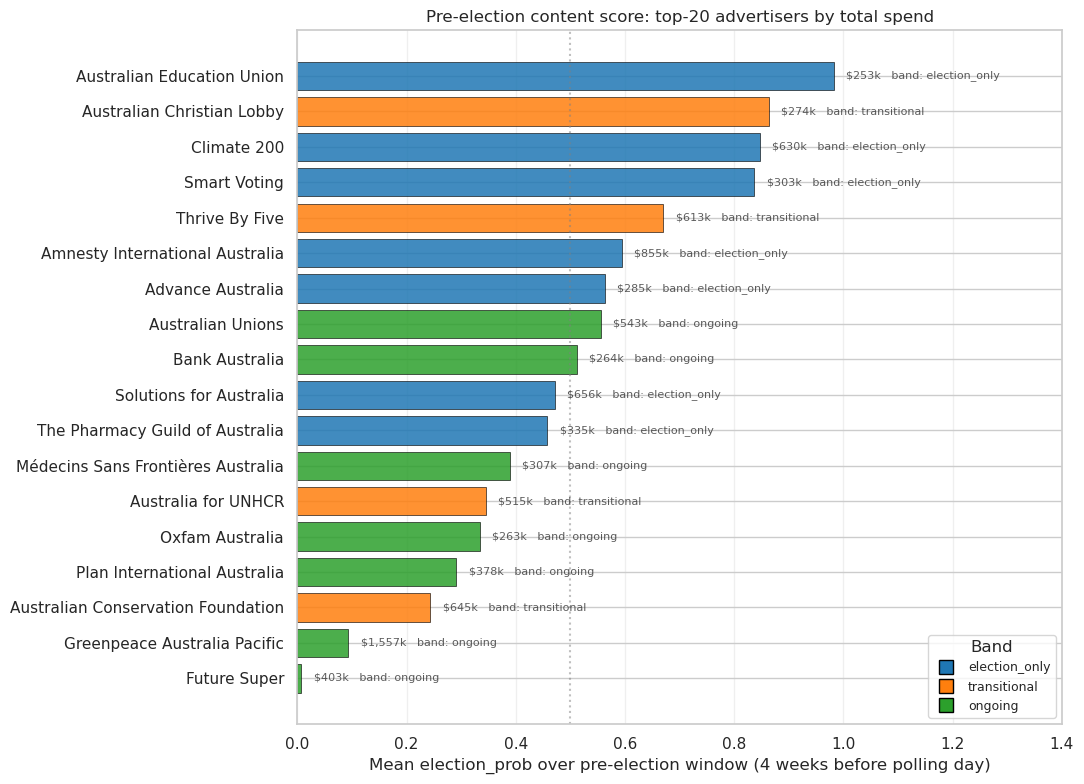

In [30]:
import numpy as np
from matplotlib.lines import Line2D

BAND_COLORS = {
    'election_only': '#1f77b4',
    'transitional':  '#ff7f0e',
    'ongoing':       '#2ca02c',
    'off_campaign':  '#d62728',
}

top20 = content_export.sort_values('total_spend', ascending=False).head(20).copy()
if have_bands:
    top20 = top20.merge(bands_pdf, on='bylines', how='left')
else:
    top20['band'] = '?'

top20 = (top20
    .dropna(subset=['mean_prob_pre'])
    .sort_values('mean_prob_pre', ascending=True)
    .reset_index(drop=True))

colours = top20['band'].map(BAND_COLORS).fillna('#888888')

fig, ax = plt.subplots(figsize=(11, 8))
y_pos = np.arange(len(top20))

ax.barh(y_pos, top20['mean_prob_pre'], color=colours,
        edgecolor='black', linewidth=0.5, alpha=0.85)

for i, (_, row) in enumerate(top20.iterrows()):
    ax.text(row['mean_prob_pre'] + 0.01, i,
            f'  ${row["total_spend"]/1000:,.0f}k   band: {row["band"]}',
            va='center', fontsize=8, alpha=0.75)

ax.axvline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels([b[:35] for b in top20['bylines']])
ax.set_xlim(0, 1.4)
ax.set_xlabel('Mean election_prob over pre-election window (4 weeks before polling day)')
ax.set_title('Pre-election content score: top-20 advertisers by total spend')

present_bands = [b for b in BAND_COLORS if b in top20['band'].values]
if len(present_bands) > 1:
    band_handles = [
        Line2D([0], [0], marker='s', linestyle='', color='w',
               markerfacecolor=BAND_COLORS[b], markeredgecolor='black',
               markersize=10, label=b)
        for b in present_bands
    ]
    ax.legend(handles=band_handles, loc='lower right', fontsize=9, title='Band')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

the pre-election content score is now in data/content_classifier_per_advertiser.csv. nb 07 joins it with the temporal classifier (nb 05) and produces the combined PAC ranking.